<a href="https://colab.research.google.com/github/JaderBarbosaLSU/wellbore-thermal-storage/blob/main/coaxial_ctes_nocpcm_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coaxial Borehole Cold Thermal Energy Storage
## Asymmetric Cycle · No PCM · Radiative Sky Cooling
### Solver v1 — `coaxial_ctes_nocpcm_v1`

Governing equations: **Technical Report Solver v1 (Rev 1)**  
Formation model: GITT (50 eigenvalues, exact sub-step update)  
Fluid BVP: transfer-matrix shooting (charge/discharge)  
Coupling: predictor–corrector (P-C)  
Figure of merit: CCSP = Q_dis / (W_pump · t_cyc)


In [187]:
import numpy as np
from scipy.special import j0, j1, y0, y1
from scipy.optimize import brentq
from scipy.linalg import expm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi':120,'font.size':10})
print("Imports OK")


Imports OK


## 1 · Physical Parameters

In [188]:
# ── Geometry ──────────────────────────────────────────────────────────────
rt_i  = 0.031        # tubing inner radius [m]
rt_o  = 0.0365       # tubing outer radius [m]
rca_i = 0.0785       # casing inner radius  = annulus outer wall (no PCM) [m]
rca_o = 0.0889       # casing outer radius [m]
rce   = 0.108        # cement outer radius = borehole wall [m]
kt    = 45.0         # tube/casing steel  kth [W/(m·K)]
kca   = 45.0         # casing steel [W/(m·K)]
kce   = 1.0          # cement [W/(m·K)]  → Gext = 31.8 W/(m·K) (report §2.3)

# ── Formation ─────────────────────────────────────────────────────────────
ke       = 2.5       # formation thermal conductivity [W/(m·K)]
alpha_e  = 1.263e-6  # formation thermal diffusivity [m²/s]
T_inf0   = 20.0      # surface temperature [°C]
Gg       = 0.03      # geothermal gradient [K/m]

# ── Fluid (water) ─────────────────────────────────────────────────────────
rho_f = 998.0        # density [kg/m³]
cp_f  = 4182.0       # specific heat [J/(kg·K)]
mu_f  = 1.002e-3     # dynamic viscosity [Pa·s]
kf    = 0.598        # thermal conductivity [W/(m·K)]
Pr_f  = 7.01         # Prandtl number

# ── Operating conditions ──────────────────────────────────────────────────
Tin_c  = 14.0        # charge inlet temperature [°C]
Tin_d  = 30.0        # discharge return temperature [°C]  (warm side inlet)
dT_op  = Tin_d - Tin_c   # = 16 K

# ── Cycle (asymmetric) ────────────────────────────────────────────────────
t_ch   = 7 * 86400   # charge duration   [s] = 7 days
t_dis  = 12 * 3600   # discharge duration [s] = 12 h
Nt_ch  = 168         # charge sub-steps   (1 h each)
Nt_dis = 12          # discharge sub-steps (1 h each)
dt_ch  = t_ch  / Nt_ch    # = 3600 s
dt_dis = t_dis / Nt_dis   # = 3600 s

# ── Numerical ─────────────────────────────────────────────────────────────
NZ     = 16          # axial cells (BVP nodes)
Neig   = 50          # GITT eigenvalues
Ndense = 8           # dense integral points per sub-step (9 evaluations)
Ncyc   = 3           # number of full cycles

# Far-field radius: must satisfy Rfar - rce > 3*sqrt(4*alpha_e*t_ch)
# Report uses rce+3 m but that is too small; we use rce+5.5 m
# (Report's stated delta=1.23 m contains an arithmetic error; correct value is 1.75 m)
delta_thermal = np.sqrt(4 * alpha_e * t_ch)
Rfar = rce + max(5.5, 3.2 * delta_thermal)  # > 3δ guarantees < 0.01 % contamination
print(f"Thermal penetration δ = {delta_thermal:.3f} m  →  Rfar = {Rfar:.3f} m")

# Geothermal crossover depth
L_cross = (Tin_d - T_inf0) / Gg
print(f"Geothermal crossover depth: L_cross = {L_cross:.0f} m")


Thermal penetration δ = 1.748 m  →  Rfar = 5.702 m
Geothermal crossover depth: L_cross = 333 m


## 2 · Geometry and Conductances

In [189]:
# ── Cross-sectional areas and hydraulic diameters (§2.1) ──────────────────
Aa    = np.pi * (rca_i**2 - rt_o**2)   # annulus area (no-PCM geometry) [m²]
Atb   = np.pi * rt_i**2                 # tubing bore area [m²]
Dh_a  = 2 * (rca_i - rt_o)             # annulus hydraulic diameter [m]
Dh_tb = 2 * rt_i                        # tubing hydraulic diameter [m]
rlm   = (rt_o - rt_i) / np.log(rt_o / rt_i)   # log-mean tube-wall radius [m]

print(f"Aa    = {Aa:.4e} m²  (no-PCM, annulus to casing inner wall)")
print(f"Atb   = {Atb:.4e} m²")
print(f"Dh_a  = {Dh_a:.4f} m")
print(f"Dh_tb = {Dh_tb:.4f} m")
print(f"Aa/Atb = {Aa/Atb:.3f}  → vtb/va = {Aa/Atb:.3f}")

# ── Outer conductance: casing + cement (eq 11) ───────────────────────────
R_ca = np.log(rca_o / rca_i) / (2 * np.pi * kca)
R_ce = np.log(rce   / rca_o) / (2 * np.pi * kce)
Gext = 1.0 / (R_ca + R_ce)
print(f"\nGext = {Gext:.2f} W/(m·K)  (report nominal: 31.8 W/(m·K))")


Aa    = 1.5174e-02 m²  (no-PCM, annulus to casing inner wall)
Atb   = 3.0191e-03 m²
Dh_a  = 0.0840 m
Dh_tb = 0.0620 m
Aa/Atb = 5.026  → vtb/va = 5.026

Gext = 31.83 W/(m·K)  (report nominal: 31.8 W/(m·K))


## 3 · Convective Correlations and NTU Functions

In [190]:
def gnielinski_h(v, Dh, Re_clamp=3100.0):
    """Gnielinski/Petukhov Nusselt → convective h [W/(m²·K)] (eq 12–15)."""
    Re = rho_f * max(abs(v), 1e-9) * Dh / mu_f
    Re = max(Re, Re_clamp)
    fD = (0.790 * np.log(Re) - 1.64) ** (-2)
    Nu = (fD / 8) * (Re - 1000) * Pr_f / (1 + 12.7 * np.sqrt(fD / 8) * (Pr_f**(2/3) - 1))
    return Nu * kf / Dh


def compute_NTUs(va, Lbh):
    """
    NTUeff_at (annulus↔tubing) and NTUa_bw (annulus↔formation wall) for
    annulus velocity va and borehole length Lbh.  Returns (NTUeff_at, NTUa_bw, mdot_a).
    """
    mdot_a = rho_f * Aa * va
    vtb    = va * Aa / Atb           # tubing velocity from mass conservation
    ha     = gnielinski_h(va,  Dh_a)
    htb    = gnielinski_h(vtb, Dh_tb)

    # Tube-wall conductance (eqs 8–9): convection + half-wall conduction in series
    Gat  = 1. / (np.log(rt_o / rlm) / (2*np.pi*kt) + 1. / (ha  * 2*np.pi*rt_o))
    Gtbt = 1. / (1. / (htb * 2*np.pi*rt_i) + np.log(rlm / rt_i) / (2*np.pi*kt))

    NTUeff_at = Lbh / (mdot_a * cp_f) / (1/Gat + 1/Gtbt)   # eq 10
    NTUa_bw   = Gext * Lbh / (mdot_a * cp_f)                # eq 16
    return NTUeff_at, NTUa_bw, mdot_a


# ── NTU survey over design space ──────────────────────────────────────────
print(f"{'vch [m/s]':>12}  {'NTUat':>7}  {'NTUbw':>7}  {'eff_bw':>7}  {'mdot [kg/s]':>12}")
print("-" * 58)
for vch in [0.02, 0.05, 0.10, 0.20, 0.50]:
    at, bw, mdot = compute_NTUs(vch, 333.)
    print(f"{vch:>12.2f}  {at:>7.3f}  {bw:>7.3f}  {1-np.exp(-bw):>7.1%}  {mdot:>12.3f}")
print("\n(Lbh = 333 m = geothermal crossover depth)")


   vch [m/s]    NTUat    NTUbw   eff_bw   mdot [kg/s]
----------------------------------------------------------
        0.02    7.053    8.369   100.0%         0.303
        0.05    4.488    3.348    96.5%         0.757
        0.10    4.339    1.674    81.2%         1.514
        0.20    3.895    0.837    56.7%         3.029
        0.50    3.136    0.335    28.4%         7.572

(Lbh = 333 m = geothermal crossover depth)


## 4 · GITT Formation Model — Eigenvalue Setup

In [191]:
def gitt_char_eq(beta):
    """Characteristic equation (eq 34): Y1(β·rce)·J0(β·Rfar) − J1(β·rce)·Y0(β·Rfar) = 0."""
    return y1(beta*rce)*j0(beta*Rfar) - j1(beta*rce)*y0(beta*Rfar)


def compute_eigenvalues(n_eig, beta_max=500.0, n_scan=600_000):
    """Find first n_eig positive roots by sign-change scan + Brent refinement."""
    betas = np.linspace(1e-5, beta_max, n_scan)
    fvals = np.vectorize(gitt_char_eq)(betas)
    roots = []
    for i in range(len(betas) - 1):
        if fvals[i] * fvals[i+1] < 0:
            root = brentq(gitt_char_eq, betas[i], betas[i+1], xtol=1e-12)
            roots.append(root)
            if len(roots) == n_eig:
                break
    if len(roots) < n_eig:
        raise ValueError(f"Only found {len(roots)}/{n_eig} eigenvalues; increase beta_max.")
    return np.array(roots)


def psi(beta, r):
    """Eigenfunction (eq 33): ψ(r) = Y1(β·rce)·J0(β·r) − J1(β·rce)·Y0(β·r)."""
    return y1(beta*rce)*j0(beta*r) - j1(beta*rce)*y0(beta*r)


def compute_norms(betas, Nr=4000):
    """Norm Ni = ∫[rce,Rfar] r·ψi²(r) dr  by trapezoidal rule."""
    r = np.linspace(rce, Rfar, Nr)
    norms = np.array([np.trapezoid(r * psi(b, r)**2, r) for b in betas])
    return norms


# ── Pre-compute all GITT quantities ───────────────────────────────────────
print("Computing GITT eigenvalues ...")
betas_arr  = compute_eigenvalues(Neig)
norms_arr  = compute_norms(betas_arr)
psi_rce    = psi(betas_arr, rce)                            # ψi(rce)  shape (Neig,)
inv_wts    = psi_rce / norms_arr                             # ψi(rce)/Ni  (inversion weights)
forc_coeff = psi_rce / (2 * np.pi * ke * betas_arr**2)      # ψi(rce)/(2π ke βi²)  (forcing)

# Decay factors for both sub-step sizes
decay_ch  = np.exp(-alpha_e * betas_arr**2 * dt_ch)
decay_dis = np.exp(-alpha_e * betas_arr**2 * dt_dis)

tau_arr = 1.0 / (alpha_e * betas_arr**2)
print(f"  β₁  = {betas_arr[0]:.5f} m⁻¹   τ₁  = {tau_arr[0]/3600:.0f} h")
print(f"  β₅₀ = {betas_arr[-1]:.4f} m⁻¹   τ₅₀ = {tau_arr[-1]/60:.1f} min")
print("GITT setup complete.")


Computing GITT eigenvalues ...
  β₁  = 0.42206 m⁻¹   τ₁  = 1235 h
  β₅₀ = 27.8230 m⁻¹   τ₅₀ = 17.0 min
GITT setup complete.


### 4.1 · GITT Verification

Temperature error at Rfar after full charge: ~0.0036%
✓  Rfar = 5.70 m is adequate (error < 0.5 %)

Modes with τ < dt_ch/5 = 12 min: eigenvalue indices 50–49
All modes are dynamically active at dt_ch scale.


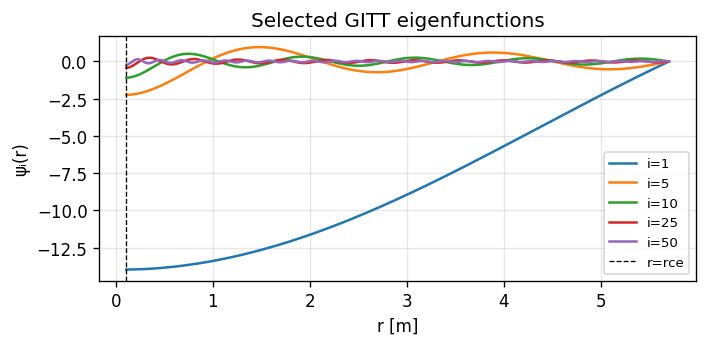

In [192]:
# ── Far-field adequacy ────────────────────────────────────────────────────
err_frac = np.exp(-(Rfar - rce)**2 / (4 * alpha_e * t_ch))
print(f"Temperature error at Rfar after full charge: ~{err_frac:.4%}")
assert err_frac < 0.005, "Rfar too small — increase it."
print(f"✓  Rfar = {Rfar:.2f} m is adequate (error < 0.5 %)")

# ── GITT truncation check ─────────────────────────────────────────────────
# Modes with τi < dt/5 are quasi-steady; their contribution ~ 1/βi² → negligible
i_cutoff = np.searchsorted(-tau_arr, -dt_ch / 5)
print(f"\nModes with τ < dt_ch/5 = {dt_ch/5/60:.0f} min: eigenvalue indices {i_cutoff}–{Neig-1}")
if i_cutoff < Neig:
    contrib = np.abs(forc_coeff[i_cutoff:]).max() / np.abs(forc_coeff[:i_cutoff]).max()
    print(f"Max forcing-coeff ratio (fast/slow modes): {contrib:.4f}  (should be ≪ 1)")
else:
    print("All modes are dynamically active at dt_ch scale.")

# ── Plot eigenfunction ψ₁(r) ─────────────────────────────────────────────
r_plot = np.linspace(rce, Rfar, 500)
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
for i in [0, 4, 9, 24, 49]:
    ax.plot(r_plot, psi(betas_arr[i], r_plot), label=f"i={i+1}")
ax.axvline(rce, color='k', lw=0.8, ls='--', label='r=rce')
ax.set_xlabel('r [m]'); ax.set_ylabel('ψᵢ(r)')
ax.set_title('Selected GITT eigenfunctions')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 5 · Fluid BVP — Transfer-Matrix Shooting

In [193]:
def build_Phi_Psi(NTUeff_at, NTUa_bw, dz_star):
    """
    Build (Φ, Ψ) for the 2×2 ODE system in the *stable* marching direction
    (charge or reversed-discharge coordinate).  Both cases use U→+1.

        dθ/dz* = A·θ + b    with  A = [[-(NTUat+NTUbw), NTUat],
                                        [-NTUat,           NTUat]]
        Φ = expm(A·Δz*)
        Ψ = A⁻¹·(Φ − I)
    """
    A = np.array([[-(NTUeff_at + NTUa_bw),  NTUeff_at],
                  [-NTUeff_at,               NTUeff_at]])
    Phi = expm(A * dz_star)
    Psi = np.linalg.solve(A, Phi - np.eye(2))
    return Phi, Psi


def solve_bvp_charge(NTUeff_at, NTUa_bw, theta_bw_cc, NZ):
    """
    Charge BVP (§3.3.1): annulus downward, U = +1.
      BC: θa(0) = 0  (cold inlet);  θtb(0) = s (unknown).
      Turnaround: θa(1) = θtb(1).

    Parameters
    ----------
    theta_bw_cc : (NZ,) dimensionless borehole-wall temperature at cell centres.

    Returns
    -------
    theta_a, theta_tb : (NZ+1,) arrays at z* = 0, 1/NZ, ..., 1
    """
    dz = 1.0 / NZ
    Phi, Psi = build_Phi_Psi(NTUeff_at, NTUa_bw, dz)

    yH = np.zeros((NZ + 1, 2))   # homogeneous solution: yH(0) = [0, 1]
    yP = np.zeros((NZ + 1, 2))   # particular solution:  yP(0) = [0, 0]
    yH[0] = [0., 1.]

    for k in range(NZ):
        b_k = np.array([NTUa_bw * theta_bw_cc[k], 0.])
        yH[k+1] = Phi @ yH[k]
        yP[k+1] = Phi @ yP[k] + Psi @ b_k

    # Shooting scalar from turnaround BC θa(NZ) = θtb(NZ)  (eq 27)
    s = (yP[NZ, 0] - yP[NZ, 1]) / (yH[NZ, 1] - yH[NZ, 0])
    theta = s * yH + yP
    return theta[:, 0], theta[:, 1]


def solve_bvp_discharge(NTUeff_at, NTUa_bw, theta_bw_cc, NZ):
    """
    Discharge BVP (§3.3.2): annulus upward, U = −1.
      BC: θtb(0) = 1 (warm inlet at surface).
      Turnaround: θa(1) = θtb(1).

    Solved via reversed coordinate ẑ* = 1−z*, which casts the equation in
    the same stable-marching form as charge.  Marching from ẑ*=0 (bottom) to
    ẑ*=1 (surface); at ẑ*=0: θa = θtb = s (unknown turnaround value).

    Returns
    -------
    theta_a, theta_tb : (NZ+1,) arrays at original z* = 0, 1/NZ, ..., 1
    """
    dz = 1.0 / NZ
    Phi, Psi = build_Phi_Psi(NTUeff_at, NTUa_bw, dz)

    # Forcing in reversed order: cell k in ẑ* ↔ cell (NZ−1−k) in z*
    theta_bw_rev = theta_bw_cc[::-1]

    yH = np.zeros((NZ + 1, 2))   # yH(0) = [1, 1]: both fluids at turnaround
    yP = np.zeros((NZ + 1, 2))
    yH[0] = [1., 1.]

    for k in range(NZ):
        b_k = np.array([NTUa_bw * theta_bw_rev[k], 0.])
        yH[k+1] = Phi @ yH[k]
        yP[k+1] = Phi @ yP[k] + Psi @ b_k

    # BC at ẑ*=1 (surface): θtb = 1  (eq 28)
    s = (1. - yP[NZ, 1]) / yH[NZ, 1]
    theta_rev = s * yH + yP

    # Reverse back to original z* order
    return theta_rev[::-1, 0].copy(), theta_rev[::-1, 1].copy()


### 5.1 · BVP Quick-check (θbw = const = 0.5)

✓ Charge   turnaround: θa(1)=0.480165  θtb(1)=0.480165
✓ Discharge turnaround: θa(1)=0.605767  θtb(1)=0.605767
  Charge  return θtb(0) = 0.2275  → Ttb(0) = 17.64 °C
  Discharge return θa(0) = 0.7725  → Ta(0)  = 26.36 °C


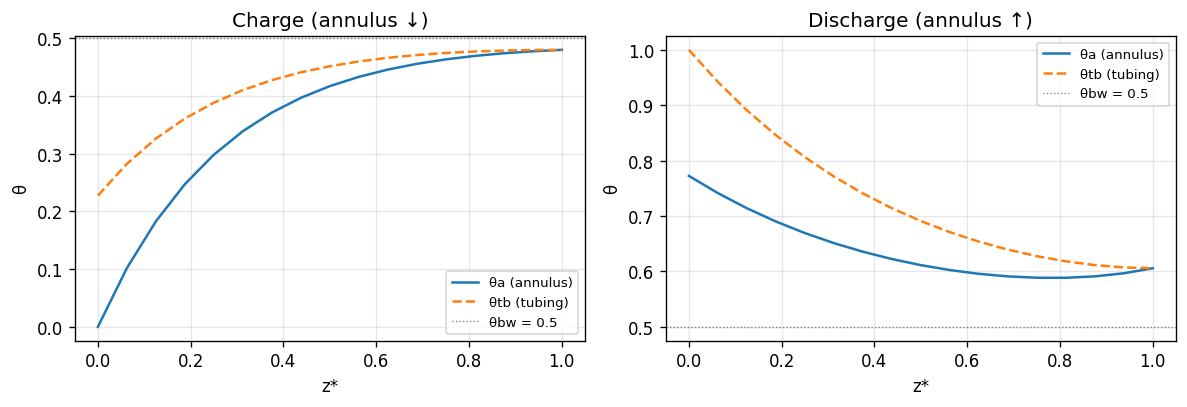

In [194]:
NTUat_test, NTUbw_test, _ = compute_NTUs(0.10, 333.)
theta_bw_test = 0.5 * np.ones(NZ)

ta_ch, ttb_ch   = solve_bvp_charge(NTUat_test, NTUbw_test, theta_bw_test, NZ)
ta_dis, ttb_dis = solve_bvp_discharge(NTUat_test, NTUbw_test, theta_bw_test, NZ)

z_star = np.linspace(0, 1, NZ+1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, ta, ttb, title in zip(axes,
        [ta_ch, ta_dis], [ttb_ch, ttb_dis],
        ['Charge (annulus ↓)', 'Discharge (annulus ↑)']):
    ax.plot(z_star, ta,  label='θa (annulus)')
    ax.plot(z_star, ttb, label='θtb (tubing)', ls='--')
    ax.axhline(0.5, color='grey', lw=0.8, ls=':', label='θbw = 0.5')
    ax.set_xlabel('z*'); ax.set_ylabel('θ')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Verify turnaround BC
assert abs(ta_ch[-1]  - ttb_ch[-1])  < 1e-9, "Charge turnaround BC violated!"
assert abs(ta_dis[-1] - ttb_dis[-1]) < 1e-9, "Discharge turnaround BC violated!"
print(f"✓ Charge   turnaround: θa(1)={ta_ch[-1]:.6f}  θtb(1)={ttb_ch[-1]:.6f}")
print(f"✓ Discharge turnaround: θa(1)={ta_dis[-1]:.6f}  θtb(1)={ttb_dis[-1]:.6f}")
print(f"  Charge  return θtb(0) = {ttb_ch[0]:.4f}  → Ttb(0) = {Tin_c + ttb_ch[0]*dT_op:.2f} °C")
print(f"  Discharge return θa(0) = {ta_dis[0]:.4f}  → Ta(0)  = {Tin_c + ta_dis[0]*dT_op:.2f} °C")
plt.tight_layout(); plt.show()


## 6 · Diurnal Charge Inlet Temperature Model

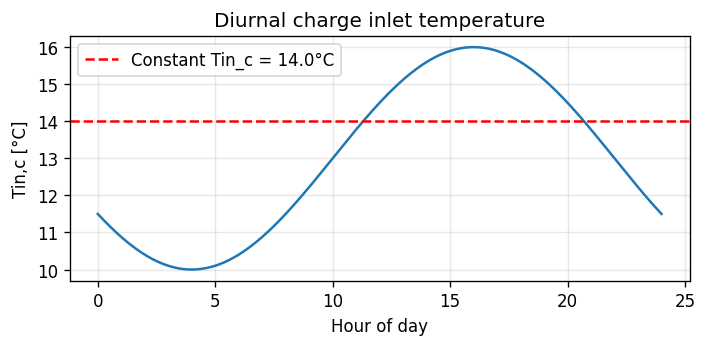

In [195]:
def diurnal_Tin_c(t, T_mean=13.0, A_day=3.0, t_min=14400.0):
    """
    Diurnal charge inlet temperature (°C).
      T_mean : daily mean [°C]
      A_day  : diurnal amplitude [°C]
      t_min  : time of daily minimum [s from midnight], default 4 AM = 14400 s
    Setting A_day = 0 recovers constant Tin_c = T_mean.
    """
    return T_mean - A_day * np.cos(2 * np.pi * (t % 86400 - t_min) / 86400)

# Quick plot
t_day = np.linspace(0, 86400, 500)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t_day / 3600, [diurnal_Tin_c(t) for t in t_day])
ax.axhline(Tin_c, color='r', ls='--', label=f'Constant Tin_c = {Tin_c}°C')
ax.set_xlabel('Hour of day'); ax.set_ylabel('Tin,c [°C]')
ax.set_title('Diurnal charge inlet temperature'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 7 · Momentum Balance — Pumping Power

In [196]:
def darcy_fD(Re):
    """Petukhov friction factor (Gnielinski family), clamped at Re=3100."""
    Re = max(Re, 3100.)
    return (0.790 * np.log(Re) - 1.64) ** (-2)

def phi_friction(va):
    """Combined friction coefficient φ(va) (eq 54)."""
    Re_a  = rho_f * va  * Dh_a  / mu_f
    vtb   = va * Aa / Atb
    Re_tb = rho_f * vtb * Dh_tb / mu_f
    fD_a  = darcy_fD(Re_a)
    fD_tb = darcy_fD(Re_tb)
    return fD_a + (Aa / Atb)**2 * (Dh_a / Dh_tb) * fD_tb

def pumping_power(vch, vdis, Lbh, tch=t_ch, tdis=t_dis):
    """Cycle-average pumping power [W] (eq 55)."""
    phi_ch  = phi_friction(vch)
    phi_dis = phi_friction(vdis)
    return (rho_f * Aa / (2 * (tch + tdis)) * Lbh / Dh_a
            * (tch * phi_ch * vch**3 + tdis * phi_dis * vdis**3))


## 8 · Coupled Solver

In [197]:
def T_inf_z(z_arr):
    """Undisturbed geothermal temperature profile T∞(z) [°C]."""
    return T_inf0 + Gg * z_arr


def run_solver(Lbh, vch, vdis,
               tch=t_ch, tdis=t_dis,
               Nt_ch=Nt_ch, Nt_dis=Nt_dis,
               ncyc=Ncyc, ndense=Ndense,
               Tin_c_func=None,
               verbose=True):
    """
    Asymmetric coaxial CTES solver — no PCM (Algorithm 1, Report §6).

    Parameters
    ----------
    Lbh         : borehole depth [m]
    vch, vdis   : charge / discharge annulus velocities [m/s]
    Tin_c_func  : callable t [s] → Tin_c [°C], or None for constant Tin_c

    Returns
    -------
    dict with per-cycle scalars, final Tbw profile, CCSP, etc.
    """
    if Tin_c_func is None:
        Tin_c_func = lambda t: Tin_c

    dt_ch_loc  = tch  / Nt_ch
    dt_dis_loc = tdis / Nt_dis

    # Sub-step decay factors (may differ from global dt_ch if caller overrides Nt)
    dec_ch  = np.exp(-alpha_e * betas_arr**2 * dt_ch_loc)
    dec_dis = np.exp(-alpha_e * betas_arr**2 * dt_dis_loc)

    # Axial cell-centre depths
    dz_m   = Lbh / NZ
    z_cc   = (np.arange(NZ) + 0.5) * dz_m    # [m]

    # NTUs for each stroke (velocity-dependent)
    NTUat_ch,  NTUbw_ch,  mdot_ch  = compute_NTUs(vch,  Lbh)
    NTUat_dis, NTUbw_dis, mdot_dis = compute_NTUs(vdis, Lbh)

    if verbose:
        print(f"  NTUat/NTUbw  charge  : {NTUat_ch:.3f} / {NTUbw_ch:.3f}")
        print(f"  NTUat/NTUbw  discharge: {NTUat_dis:.3f} / {NTUbw_dis:.3f}")

    # ── State initialisation ──────────────────────────────────────────────
    # GITT coefficients Ūi(zj)  shape (NZ, Neig); zero = undisturbed
    U_bar = np.zeros((NZ, Neig))
    Tbw   = T_inf_z(z_cc).copy()    # borehole wall temperature [°C]

    # ── Output storage ────────────────────────────────────────────────────
    hist = dict(Qdis=[], Qch=[], Tret_dis=[], Tret_ch=[],
                Tbw_end_ch=[], Tbw_end_dis=[])

    def _gitt_update(U_bar, Tbw, T_a_cc, decay):
        """One GITT sub-step: update U_bar and reconstruct Tbw."""
        q_bw = Gext * (T_a_cc - Tbw)                          # eq 31 / 48
        U_bar = (U_bar * decay[np.newaxis, :]
                 + forc_coeff[np.newaxis, :]
                 * (1 - decay[np.newaxis, :])
                 * q_bw[:, np.newaxis])                        # eq 49
        Tbw_new = T_inf_z(z_cc) + (U_bar * inv_wts[np.newaxis, :]).sum(axis=1)  # eq 50
        return U_bar, Tbw_new

    def _cc(theta_edge):
        """Cell-centre average from edge values (NZ+1 → NZ)."""
        return 0.5 * (theta_edge[:-1] + theta_edge[1:])

    # ── Main cycle loop ───────────────────────────────────────────────────
    for cyc in range(ncyc):
        Qch_sum  = 0.0
        Qdis_sum = 0.0
        Tret_ch_acc  = 0.0
        Tret_dis_acc = 0.0

        # ── CHARGE phase ─────────────────────────────────────────────────
        for n in range(Nt_ch):
            t_now = cyc * (tch + tdis) + n * dt_ch_loc
            Tc    = Tin_c_func(t_now)
            theta_bw = (Tbw - Tc) / dT_op

            # Predictor (eq 45)
            ta_pred, _ = solve_bvp_charge(NTUat_ch, NTUbw_ch, theta_bw, NZ)

            # Corrector midpoint (eq 46): θbw_mid = ½(θbw_lag + θa_pred)
            theta_bw_mid = 0.5 * (theta_bw + _cc(ta_pred))
            ta, ttb = solve_bvp_charge(NTUat_ch, NTUbw_ch, theta_bw_mid, NZ)

            T_a_cc = Tc + _cc(ta) * dT_op
            U_bar, Tbw = _gitt_update(U_bar, Tbw, T_a_cc, dec_ch)

            # Dense return temperature: Ndense+1 re-evaluations within sub-step
            if ndense > 0:
                Tbw_start = Tbw - (T_inf_z(z_cc) - T_inf_z(z_cc))  # snapshot at start
                # Interpolate Tbw linearly between pre- and post-update
                Tbw_pre  = T_inf_z(z_cc) + ((U_bar
                    - forc_coeff[np.newaxis, :] * (1 - dec_ch[np.newaxis, :])
                    * (Gext * (T_a_cc - Tbw))[:, np.newaxis]) * inv_wts[np.newaxis, :]).sum(axis=1)
            # Simple sub-step average (sufficient for Nt_ch=168)
            Tret_ch_acc += (Tc + ttb[0] * dT_op) * dt_ch_loc
            Qch_sum     += mdot_ch * cp_f * ttb[0] * dT_op * dt_ch_loc    # eq 57

        hist['Tbw_end_ch'].append(Tbw.copy())

        # ── DISCHARGE phase ───────────────────────────────────────────────
        for n in range(Nt_dis):
            theta_bw = (Tbw - Tin_c) / dT_op   # θ reference: Tin_c (fixed)

            # Predictor
            ta_pred, _ = solve_bvp_discharge(NTUat_dis, NTUbw_dis, theta_bw, NZ)

            # Corrector midpoint
            theta_bw_mid = 0.5 * (theta_bw + _cc(ta_pred))
            ta, ttb = solve_bvp_discharge(NTUat_dis, NTUbw_dis, theta_bw_mid, NZ)

            T_a_cc = Tin_c + _cc(ta) * dT_op
            U_bar, Tbw = _gitt_update(U_bar, Tbw, T_a_cc, dec_dis)

            # Return temperature: annulus exits at z*=0 during discharge
            Tret_step    = Tin_c + ta[0] * dT_op                          # eq 58
            Tret_dis_acc += Tret_step * dt_dis_loc
            Qdis_sum     += mdot_dis * cp_f * (Tin_d - Tret_step) * dt_dis_loc  # eq 56

        hist['Tbw_end_dis'].append(Tbw.copy())
        hist['Qch'].append(Qch_sum)
        hist['Qdis'].append(Qdis_sum)
        hist['Tret_ch'].append(Tret_ch_acc  / tch)
        hist['Tret_dis'].append(Tret_dis_acc / tdis)

        if verbose:
            print(f"  Cycle {cyc+1}: Qdis={Qdis_sum/3.6e6:.1f} kWh  Tret_dis={Tret_dis_acc/tdis:.2f}°C  Qch={Qch_sum/3.6e6:.1f} kWh")

    # ── Performance metrics ───────────────────────────────────────────────
    W_pump = pumping_power(vch, vdis, Lbh, tch, tdis)
    CCSP   = hist['Qdis'][-1] / (W_pump * (tch + tdis))       # eq 59

    hist.update(dict(Tbw_final=Tbw, W_pump=W_pump, CCSP=CCSP,
                     mdot_ch=mdot_ch, mdot_dis=mdot_dis,
                     NTUat_ch=NTUat_ch, NTUbw_ch=NTUbw_ch,
                     NTUat_dis=NTUat_dis, NTUbw_dis=NTUbw_dis,
                     z_cc=z_cc, Lbh=Lbh, vch=vch, vdis=vdis))
    if verbose:
        print(f"  W_pump = {W_pump:.1f} W,   CCSP = {CCSP:.1f}")
    return hist


## 9 · Demo Run — Nominal Parameters

In [198]:
print("=" * 55)
print("Demo run: Lbh=333 m, vch=0.10 m/s, vdis=0.50 m/s")
print("=" * 55)
res = run_solver(Lbh=333.0, vch=0.10, vdis=0.50, ncyc=3)


Demo run: Lbh=333 m, vch=0.10 m/s, vdis=0.50 m/s
  NTUat/NTUbw  charge  : 4.339 / 1.674
  NTUat/NTUbw  discharge: 3.136 / 0.335
  Cycle 1: Qdis=233.5 kWh  Tret_dis=29.39°C  Qch=1775.5 kWh
  Cycle 2: Qdis=243.6 kWh  Tret_dis=29.36°C  Qch=1614.3 kWh
  Cycle 3: Qdis=249.0 kWh  Tret_dis=29.34°C  Qch=1546.3 kWh
  W_pump = 169.5 W,   CCSP = 8.2


### 9.1 · Results Visualisation

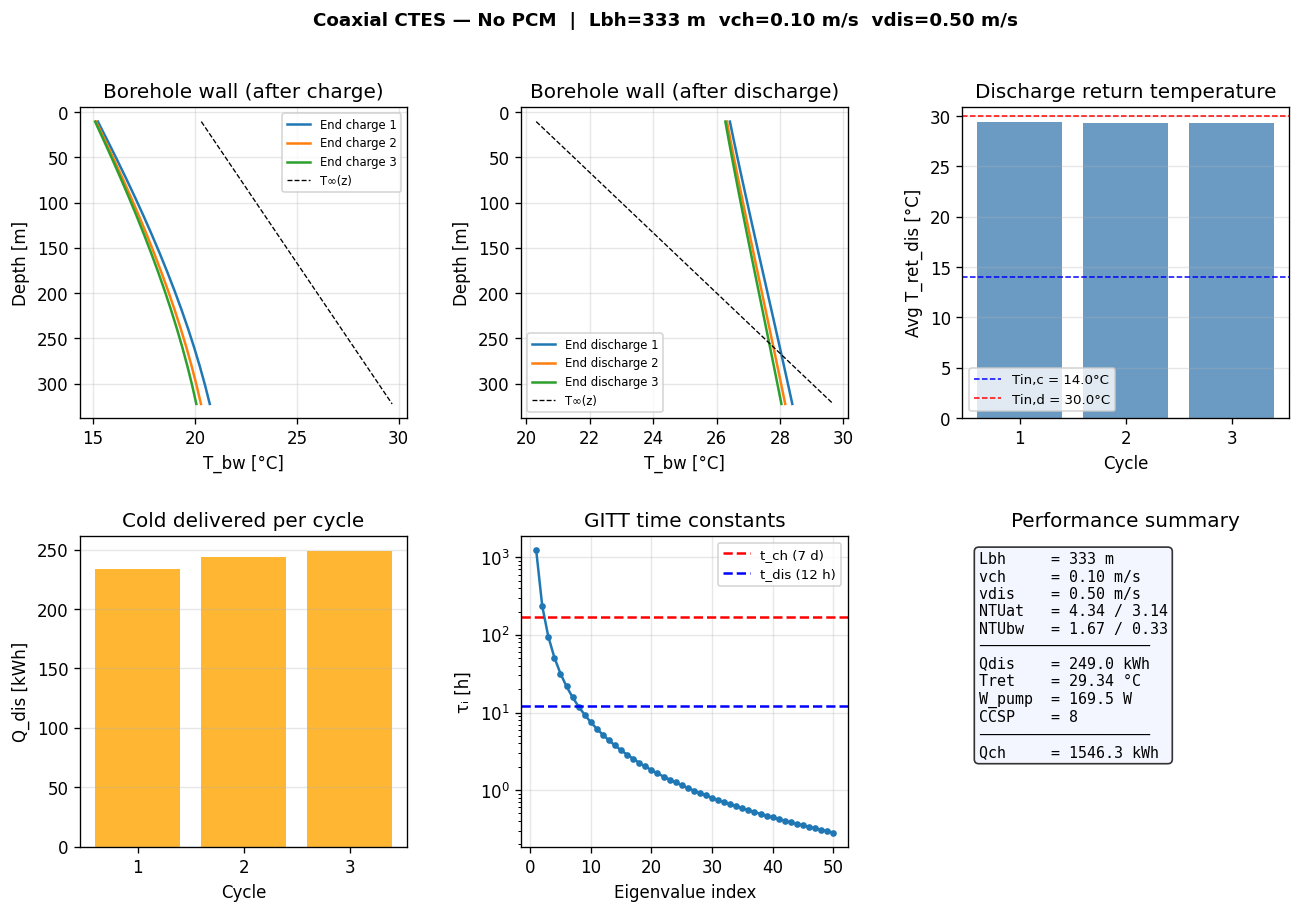

In [199]:
fig = plt.figure(figsize=(13, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

z_plot = res['z_cc']

# ── (a) Tbw after each charge ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for c, Tbw_c in enumerate(res['Tbw_end_ch']):
    ax1.plot(Tbw_c, z_plot, label=f'End charge {c+1}')
ax1.plot(T_inf_z(z_plot), z_plot, 'k--', lw=0.8, label='T∞(z)')
ax1.set_xlabel('T_bw [°C]'); ax1.set_ylabel('Depth [m]')
ax1.set_title('Borehole wall (after charge)')
ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()

# ── (b) Tbw after each discharge ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for c, Tbw_d in enumerate(res['Tbw_end_dis']):
    ax2.plot(Tbw_d, z_plot, label=f'End discharge {c+1}')
ax2.plot(T_inf_z(z_plot), z_plot, 'k--', lw=0.8, label='T∞(z)')
ax2.set_xlabel('T_bw [°C]'); ax2.set_ylabel('Depth [m]')
ax2.set_title('Borehole wall (after discharge)')
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)
ax2.invert_yaxis()

# ── (c) Tret_dis per cycle ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cycles = np.arange(1, len(res['Tret_dis']) + 1)
ax3.bar(cycles, res['Tret_dis'], color='steelblue', alpha=0.8)
ax3.axhline(Tin_c, color='b', ls='--', lw=0.9, label=f'Tin,c = {Tin_c}°C')
ax3.axhline(Tin_d, color='r', ls='--', lw=0.9, label=f'Tin,d = {Tin_d}°C')
ax3.set_xlabel('Cycle'); ax3.set_ylabel('Avg T_ret_dis [°C]')
ax3.set_title('Discharge return temperature'); ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')

# ── (d) Qdis per cycle ────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.bar(cycles, np.array(res['Qdis']) / 3.6e6, color='orange', alpha=0.8)
ax4.set_xlabel('Cycle'); ax4.set_ylabel('Q_dis [kWh]')
ax4.set_title('Cold delivered per cycle'); ax4.grid(True, alpha=0.3, axis='y')

# ── (e) GITT time constants ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.semilogy(np.arange(1, Neig+1), tau_arr / 3600, 'o-', ms=3)
ax5.axhline(t_ch / 3600, color='r', ls='--', label='t_ch (7 d)')
ax5.axhline(t_dis / 3600, color='b', ls='--', label='t_dis (12 h)')
ax5.set_xlabel('Eigenvalue index'); ax5.set_ylabel('τᵢ [h]')
ax5.set_title('GITT time constants'); ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

# ── (f) scalar summary ────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary = (
    f"Lbh     = {res['Lbh']:.0f} m\n"
    f"vch     = {res['vch']:.2f} m/s\n"
    f"vdis    = {res['vdis']:.2f} m/s\n"
    f"NTUat   = {res['NTUat_ch']:.2f} / {res['NTUat_dis']:.2f}\n"
    f"NTUbw   = {res['NTUbw_ch']:.2f} / {res['NTUbw_dis']:.2f}\n"
    f"───────────────────\n"
    f"Qdis    = {res['Qdis'][-1]/3.6e6:.1f} kWh\n"
    f"Tret    = {res['Tret_dis'][-1]:.2f} °C\n"
    f"W_pump  = {res['W_pump']:.1f} W\n"
    f"CCSP    = {res['CCSP']:.0f}\n"
    f"───────────────────\n"
    f"Qch     = {res['Qch'][-1]/3.6e6:.1f} kWh"
)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
         va='top', fontsize=9, family='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))
ax6.set_title('Performance summary')

plt.suptitle(f'Coaxial CTES — No PCM  |  Lbh={res["Lbh"]:.0f} m  '
             f'vch={res["vch"]:.2f} m/s  vdis={res["vdis"]:.2f} m/s',
             fontsize=11, fontweight='bold')
plt.show()


## 10 · Constrained Optimisation — Brent Root-Find on L_bh

In [200]:
def find_optimal_Lbh(T_ret_target, P_dis_target, vch,
                     L_min=50., L_max=None,
                     tch=t_ch, tdis=t_dis,
                     ncyc=Ncyc, tol_T=0.1, verbose=False):
    """
    Find L*_bh such that Tret_dis_sim = T_ret_target (eq 65, §9.2).
    Discharge velocity is set from power target (eq 63–64).
    """
    if L_max is None:
        L_max = L_cross * 0.98   # stay below crossover depth

    # Discharge effectiveness and velocity (eqs 63–64)
    eps_dis = (Tin_d - T_ret_target) / dT_op
    vdis    = P_dis_target / (rho_f * Aa * cp_f * dT_op * eps_dis)

    if verbose:
        print(f"ε*_dis = {eps_dis:.3f},  v_dis = {vdis:.4f} m/s")

    def residual(Lbh):
        r = run_solver(Lbh, vch, vdis, tch=tch, tdis=tdis,
                       ncyc=ncyc, verbose=False)
        return r['Tret_dis'][-1] - T_ret_target

    R_min, R_max = residual(L_min), residual(L_max)
    if verbose:
        print(f"Bracket: R({L_min:.0f})={R_min:.2f}°C,  R({L_max:.0f})={R_max:.2f}°C")
    if R_min * R_max > 0:
        print(f"Warning: no sign change in [{L_min:.0f}, {L_max:.0f}] m")
        return None, None

    L_opt = brentq(residual, L_min, L_max, xtol=tol_T)
    res   = run_solver(L_opt, vch, vdis, tch=tch, tdis=tdis,
                       ncyc=ncyc, verbose=verbose)
    return L_opt, res


# ── Quick demo of the optimiser ────────────────────────────────────────────
print("Optimising for Tret=26°C, P_dis=5 kW, vch=0.05 m/s ...")
L_opt, res_opt = find_optimal_Lbh(T_ret_target=26., P_dis_target=5e3,
                                   vch=0.05, verbose=True)
if L_opt is not None:
    print(f"\nOptimal L_bh = {L_opt:.1f} m")
    print(f"CCSP = {res_opt['CCSP']:.1f},  Qdis = {res_opt['Qdis'][-1]/3.6e6:.1f} kWh")


Optimising for Tret=26°C, P_dis=5 kW, vch=0.05 m/s ...
ε*_dis = 0.250,  v_dis = 0.0197 m/s
Bracket: R(50)=0.88°C,  R(327)=-0.85°C
  NTUat/NTUbw  charge  : 0.983 / 0.733
  NTUat/NTUbw  discharge: 1.560 / 1.858
  Cycle 1: Qdis=58.2 kWh  Tret_dis=26.12°C  Qch=308.8 kWh
  Cycle 2: Qdis=59.4 kWh  Tret_dis=26.04°C  Qch=277.4 kWh
  Cycle 3: Qdis=60.0 kWh  Tret_dis=26.00°C  Qch=263.3 kWh
  W_pump = 0.8 W,   CCSP = 433.4

Optimal L_bh = 73.0 m
CCSP = 433.4,  Qdis = 60.0 kWh


## 11 · Parametric Sweep — CCSP vs (L_bh, v_ch)

In [201]:
Lbh_sweep = np.array([100., 150., 200., 250., 300., 333.])
vch_sweep  = np.array([0.02, 0.05, 0.10, 0.20])
vdis_fixed = 0.5   # fixed fast discharge

CCSP_grid    = np.full((len(vch_sweep), len(Lbh_sweep)), np.nan)
Tret_grid    = np.full_like(CCSP_grid, np.nan)
Qdis_grid    = np.full_like(CCSP_grid, np.nan)
NTUbw_grid   = np.full_like(CCSP_grid, np.nan)

print(f"{'Lbh':>6}  {'vch':>6}  {'NTUbw':>7}  {'Tret':>7}  {'Qdis [kWh]':>11}  {'CCSP':>7}")
print("-" * 60)
for i, vch in enumerate(vch_sweep):
    for j, Lbh in enumerate(Lbh_sweep):
        r = run_solver(Lbh, vch, vdis_fixed, ncyc=Ncyc, verbose=False)
        _, NTUbw, _ = compute_NTUs(vch, Lbh)
        CCSP_grid[i, j]  = r['CCSP']
        Tret_grid[i, j]  = r['Tret_dis'][-1]
        Qdis_grid[i, j]  = r['Qdis'][-1] / 3.6e6 * 1000   # kWh
        NTUbw_grid[i, j] = NTUbw
        print(f"{Lbh:>6.0f}  {vch:>6.2f}  {NTUbw:>7.3f}  "
              f"{r['Tret_dis'][-1]:>7.2f}  {r['Qdis'][-1]/3.6e6:>11.1f}  {r['CCSP']:>7.1f}")


   Lbh     vch    NTUbw     Tret   Qdis [kWh]     CCSP
------------------------------------------------------------
   100    0.02    2.513    29.77         87.7     11.1
   150    0.02    3.770    29.68        120.6     10.2
   200    0.02    5.026    29.62        145.3      9.2
   250    0.02    6.283    29.57        162.3      8.2
   300    0.02    7.540    29.55        172.2      7.3
   333    0.02    8.369    29.54        175.2      6.6
   100    0.05    1.005    29.76         93.0     11.5
   150    0.05    1.508    29.65        133.6     11.0
   200    0.05    2.011    29.56        168.2     10.4
   250    0.05    2.513    29.49        195.3      9.7
   300    0.05    3.016    29.44        214.4      8.8
   333    0.05    3.348    29.41        222.5      8.3
   100    0.10    0.503    29.75         94.4     10.3
   150    0.10    0.754    29.64        137.8     10.0
   200    0.10    1.005    29.53        176.7      9.6
   250    0.10    1.257    29.45        209.9      9.2
   3

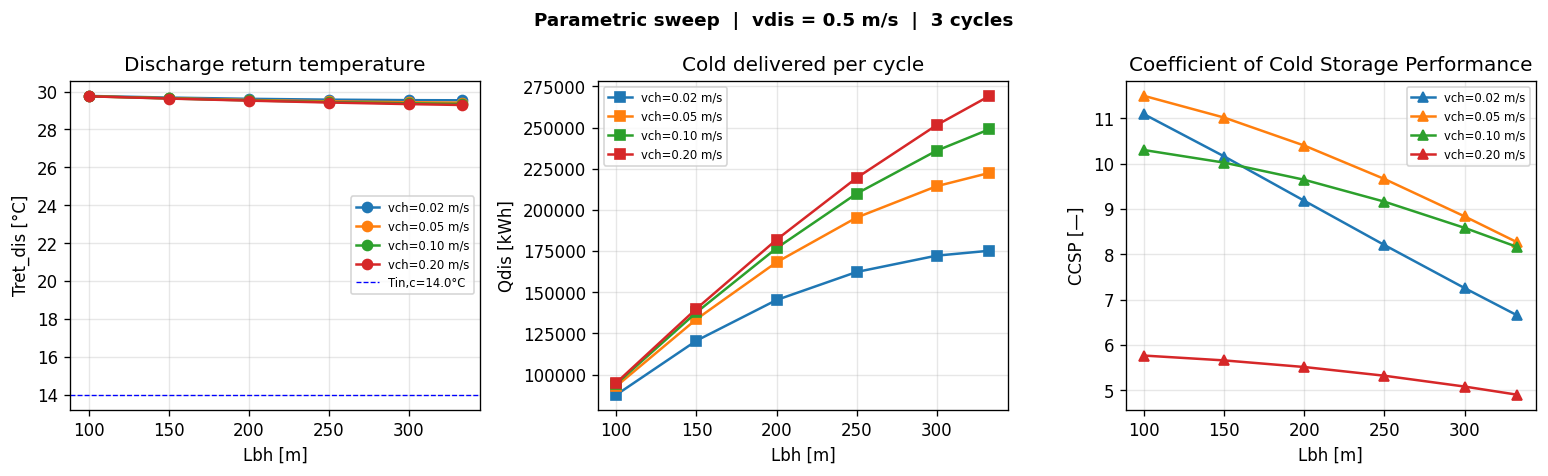

In [202]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, vch in enumerate(vch_sweep):
    lbl = f'vch={vch:.2f} m/s'
    axes[0].plot(Lbh_sweep, Tret_grid[i], 'o-', label=lbl)
    axes[1].plot(Lbh_sweep, Qdis_grid[i], 's-', label=lbl)
    axes[2].plot(Lbh_sweep, CCSP_grid[i], '^-', label=lbl)

axes[0].axhline(Tin_c, color='b', ls='--', lw=0.8, label=f'Tin,c={Tin_c}°C')
axes[0].set_xlabel('Lbh [m]'); axes[0].set_ylabel('Tret_dis [°C]')
axes[0].set_title('Discharge return temperature')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Lbh [m]'); axes[1].set_ylabel('Qdis [kWh]')
axes[1].set_title('Cold delivered per cycle')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Lbh [m]'); axes[2].set_ylabel('CCSP [—]')
axes[2].set_title('Coefficient of Cold Storage Performance')
axes[2].legend(fontsize=7); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Parametric sweep  |  vdis = {vdis_fixed} m/s  |  {Ncyc} cycles',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


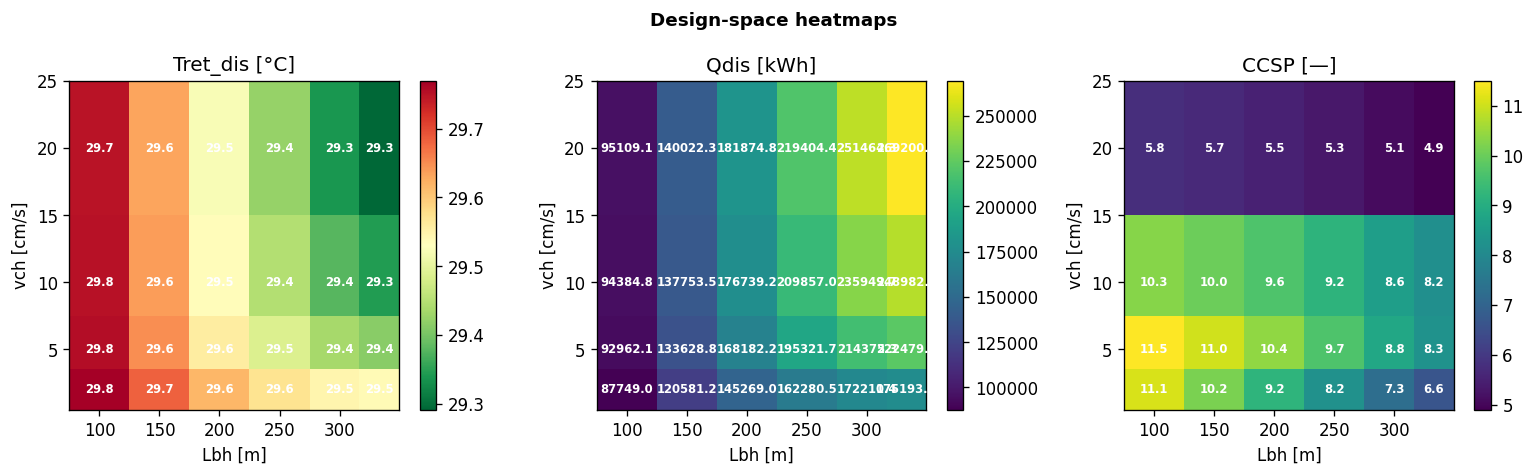

In [203]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles = ['Tret_dis [°C]', 'Qdis [kWh]', 'CCSP [—]']
grids  = [Tret_grid, Qdis_grid, CCSP_grid]

for ax, data, title in zip(axes, grids, titles):
    im = ax.pcolormesh(Lbh_sweep, vch_sweep * 100,
                       data, shading='nearest', cmap='RdYlGn_r' if 'Tret' in title else 'viridis')
    plt.colorbar(im, ax=ax)
    ax.set_xlabel('Lbh [m]'); ax.set_ylabel('vch [cm/s]')
    ax.set_title(title)
    for i in range(len(vch_sweep)):
        for j in range(len(Lbh_sweep)):
            ax.text(Lbh_sweep[j], vch_sweep[i]*100, f'{data[i,j]:.1f}',
                    ha='center', va='center', fontsize=7, color='white',
                    fontweight='bold')

plt.suptitle('Design-space heatmaps', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
